# CropSmart — NAFSI Track 1: Predictive Modeling for Agricultural Resilience

## 1. Introduction

Agriculture in the United States faces growing threats from climate variability, including shifting precipitation patterns, increased drought frequency, and unpredictable growing seasons. This challenge uses **CropSmart**, a digital twin of real-world cropping systems over the Contiguous US (CONUS), to advance agricultural monitoring and resilience.

In this challenge, you will work with three operational geospatial datasets to analyze vegetation dynamics, detect crop rotation patterns, quantify soil moisture anomalies, and build predictive models for crop type classification.

---

### Datasets

| Dataset | Description | Resolution | Period | Link |
|---|---|---|---|---|
| **Cropland Data Layer (CDL)** | Annual crop type classification for CONUS, produced by USDA NASS. Includes 100+ crop and land cover categories. | 30 m | 2008–2025 | https://croplandcros.scinet.usda.gov/ https://nassgeodata.gmu.edu/CropScape/ |
| **Vegetation Index (NDVI)** | Daily and weekly composite NDVI derived from MODIS. Captures crop phenology and greenness dynamics. | 250 m | 2000–2026 | https://cloud.csiss.gmu.edu/CropSmart/ |
| **Soil Moisture (SMAP)** | Daily and weekly surface soil moisture estimates from NASA's Soil Moisture Active Passive mission. | 9 km | 2015–2025 | https://cloud.csiss.gmu.edu/CropSmart/ |

---

### CropSmart Web Services

You may use **CropSmart map and geoprocessing services** to access and process these datasets as needed. CropSmart provides WMS (Web Map Service) and WPS (Web Processing Service) endpoints for all three datasets.

> **Documentation:** [https://cloud.csiss.gmu.edu/CropSmart-documentation](https://cloud.csiss.gmu.edu/CropSmart-documentation)

Refer to the documentation for available layers, service endpoints, spatial/temporal parameters, and example requests. The introduction section below demonstrates how to fetch and display data using the WMS interface.

### Get Data via WMS/WPS

The following cells demonstrate how to request and display map images from the CropSmart web services. Each map covers the full CONUS extent in the EPSG:5070 (Albers Equal Area) projection.

In [4]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [5]:
def fetch_wms_image(url):
    """Fetch a map image from a WMS endpoint and return a PIL Image."""
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert("RGBA")

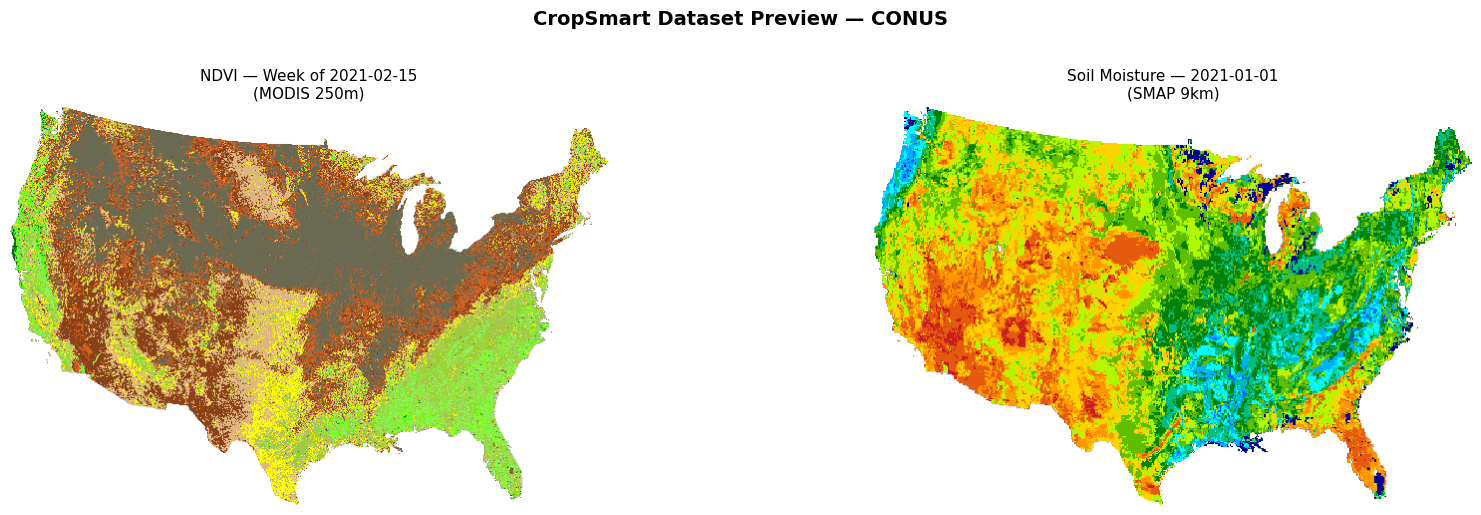

In [6]:
# WMS endpoints for the three datasets (CONUS extent, EPSG:5070)
wms_urls = {
    # "CDL 2025\n(Cropland Data Layer)": (
    #     "https://nassgeodata.gmu.edu/CropScapeService/wms_cdlall.cgi"
    #     "?SERVICE=WMS&VERSION=1.1.1&REQUEST=GetMap"
    #     "&LAYERS=cdl_2025&TRANSPARENT=true&SRS=EPSG:5070"
    #     "&BBOX=-2354935.721,311822.402,2256319.225,3165592.366"
    #     "&FORMAT=image/png&WIDTH=600&HEIGHT=400"
    # ),
    "NDVI — Week of 2021-02-15\n(MODIS 250m)": (
        "https://cloud.csiss.gmu.edu/smap_server/cgi-bin/mapserv"
        "?SERVICE=WMS&VERSION=1.3.0&REQUEST=GetMap"
        "&MAP=/WMS/NDVI-WEEKLY_2021.map"
        "&LAYERS=NDVI-WEEKLY_2021_07_2021.02.15_2021.02.21"
        "&CRS=EPSG%3A5070&FORMAT=image%2Fpng&TRANSPARENT=true"
        "&BBOX=-2354935.721,311822.402,2256319.225,3165592.366"
        "&WIDTH=600&HEIGHT=400"
    ),
    "Soil Moisture — 2021-01-01\n(SMAP 9km)": (
        "https://cloud.csiss.gmu.edu/smap_server/cgi-bin/mapserv"
        "?SERVICE=WMS&VERSION=1.3.0&REQUEST=GetMap"
        "&MAP=/WMS/SMAP-9KM-DAILY-SUB_2021.map"
        "&LAYERS=SMAP-9KM-DAILY-SUB_2021.01.01_AVERAGE"
        "&CRS=EPSG%3A5070&FORMAT=image%2Fpng&TRANSPARENT=true"
        "&BBOX=-2354935.721,311822.402,2256319.225,3165592.366"
        "&WIDTH=600&HEIGHT=400"
    ),
}

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("CropSmart Dataset Preview — CONUS", fontsize=14, fontweight="bold", y=1.02)

for ax, (title, url) in zip(axes, wms_urls.items()):
    img = fetch_wms_image(url)
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

Code example of getting the dataset through WPS.

In [7]:
url = 'https://cloud.csiss.gmu.edu/smap_service?service=WPS&version=1.0.0&request=Execute&identifier=GetFileByFips&DataInputs=layer=SMAP-9KM-DAILY-SUB_2020.01.01_013000;fips=06'

r = requests.get(url)

r.content

b'<?xml version="1.0" encoding="UTF-8"?>\n<!-- PyWPS 4.4.2 -->\n<ows:ExceptionReport xmlns:ows="http://www.opengis.net/ows/1.1" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://www.opengis.net/ows/1.1 http://schemas.opengis.net/ows/1.1.0/owsExceptionReport.xsd" version="1.0.0">\n  <ows:Exception exceptionCode="ServerBusy" locator="" >\n      <ows:ExceptionText>Maximum number of parallel running processes reached. Please try later.</ows:ExceptionText>\n  </ows:Exception>\n</ows:ExceptionReport>'

---

## 2. Task 1 — NDVI Time Series Analysis by Crop Type

Using the MODIS NDVI product and the CDL as a crop type mask, extract and compare NDVI time series for **corn** and **soybean** pixels over the growing season within the study area of **U.S. Corn Belt** (e.g., Iowa, Nebraska). Your analysis should:

- Calculate mean and interquartile range of NDVI by crop type
- Visualize seasonal NDVI profiles (phenological curves) for corn vs. soybean, highlighting key growing stages (e.g., planting, green-up, peak greenness, and harvest)

**Expected output:** A figure comparing NDVI phenological curves for both crop types with uncertainty bands, and a brief interpretation of the drivers behind observed patterns.

> **Tip:** You can use the CropSmart WMS/WPS services to access CDL and NDVI layers programmatically. See the [CropSmart documentation](https://cloud.csiss.gmu.edu/CropSmart-documentation) for available endpoints and parameters.

In [ ]:
# Task 1 — Your code here


---

## 3. Task 2 — Crop Rotation Pattern Identification

Develop a method to identify parcels exhibiting **regular crop rotation** (e.g., corn-soybean annual alternation) using a **10-year CDL time series** over a Corn Belt study area. Your analysis should:

- Define a quantitative criterion for rotation regularity (e.g., alternating patterns, transition frequency)
- Classify pixels into rotation categories: regular rotation, continuous monoculture, and irregular cropping
- Map the spatial distribution of rotation patterns and compute areal statistics by class

**Expected output:** A classified rotation map, a summary table of areal statistics by rotation class, and a brief discussion of any observable spatial patterns.

> **Tip:** You can use the CropSmart WMS/WPS services to access multi-year CDL layers programmatically. See the [CropSmart documentation](https://cloud.csiss.gmu.edu/CropSmart-documentation) for available endpoints and parameters.

In [ ]:
# Task 2 — Your code here


---

## 4. Task 3 — Soil Moisture Anomaly Calculation

Using the SMAP L4 soil moisture product, calculate **soil moisture anomalies** for a defined period of interest (e.g., the 2019 Midwest flooding, the 2022 Great Plains drought, or any multi-week window of your choice) and assess the agricultural impact using CDL crop masks. Your analysis should:

- Define a baseline climatology (e.g., multi-year mean and standard deviation per calendar day or week)
- Produce spatial anomaly maps relative to the baseline
- Identify the most severely affected crop-growing regions and connect the anomalies to potential agricultural impacts

**Expected output:** Spatial anomaly maps, time series of area-averaged anomalies over cropland, and a brief interpretation linking soil moisture conditions to agricultural context.

> **Tip:** You can use the CropSmart WMS/WPS services to access SMAP and CDL layers programmatically. See the [CropSmart documentation](https://cloud.csiss.gmu.edu/CropSmart-documentation) for available endpoints and parameters.

In [ ]:
# Task 3 — Your code here


---

## 5. Task 4 — Crop Mapping Prediction Model

Train a machine learning model to **predict crop type** for at minimum three classes: **corn**, **soybean**, and a third class (e.g., winter wheat or other/non-crop). Use multi-year CDL data as both the feature source and training labels; NDVI and SMAP may optionally be incorporated. Your analysis should:

- Construct a feature matrix from CDL-derived spatial and temporal features (e.g., historical crop type sequences, neighborhood composition, transition frequencies), optionally augmented with NDVI or SMAP statistics
- Train on CDL labels from prior years (e.g., 2013–2022) and validate on a held-out year (e.g., 2023)
- Report classification performance using overall accuracy, per-class F1 score, and a confusion matrix

**Expected output:** A trained, reproducible classification pipeline; evaluation metrics; a spatial map of predicted crop types for the test year; and a brief discussion of model limitations and generalizability.

> **Tip:** You can use the CropSmart WMS/WPS services to access CDL, NDVI, and SMAP layers programmatically. See the [CropSmart documentation](https://cloud.csiss.gmu.edu/CropSmart-documentation) for available endpoints and parameters.

In [ ]:
# Task 4 — Your code here
